# Etapa 3 — Análise das Features Extraídas

**Pré-requisito:** o notebook `02_limpeza_preparacao.ipynb` deve ter sido executado primeiro.
Ele gerou o arquivo `data/processed/features.parquet` com todas as features prontas.

Este notebook explora o que foi gerado:
- Como é a janela deslizante na prática?
- Quais features têm mais variância (mais informação)?
- As classes estão bem separadas no espaço de features?
- Tem alguma feature com NaN que precisa ser tratada antes da modelagem?

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import FAULT_CLASSES, FEATURES_DATA_PATH, VALIDATION_MODE

print('Bibliotecas carregadas!')
mode_label = 'VALIDACAO' if VALIDATION_MODE else 'COMPLETO'
print(f'Modo atual: {mode_label}')

Bibliotecas carregadas!
Modo atual: VALIDACAO


## 3.1 Carregar features (geradas pelo notebook 02)

In [8]:
df = pd.read_parquet(FEATURES_DATA_PATH)

META_COLS = ['instance_id', 'fault_class', 'source_type', 'window_start']
feature_cols = [c for c in df.columns if c not in META_COLS]

print(f'Shape: {df.shape}')
print(f'Janelas totais  : {len(df):,}')
print(f'Features/janela : {len(feature_cols)}')
print(f'Instancias unicas: {df["instance_id"].nunique()}')

# Mostrar amostra de uma instancia com sensor ativo (nao-zero)
# para verificar que a normalizacao funcionou
sample = df[df['fault_class'] == 1].head(3)
display_cols = [c for c in feature_cols if 'P-TPT' in c]
print(f'\nAmostra de features P-TPT (classe 1, apos normalizacao por instancia):')
print(sample[display_cols].round(3).to_string())

Shape: (19522, 92)
Janelas totais  : 19,522
Features/janela : 88
Instancias unicas: 20

Amostra de features P-TPT (classe 1, apos normalizacao por instancia):
     P-TPT_mean  P-TPT_std  P-TPT_min  P-TPT_max  P-TPT_skewness  P-TPT_kurtosis  P-TPT_median  P-TPT_iqr  P-TPT_diff1_std  P-TPT_diff2_std  P-TPT_max_zscore
709       1.085      0.000      1.085      1.086           4.767          22.447         1.085      0.000              0.0              0.0             6.277
710       1.087      0.002      1.085      1.089           0.654          -1.167         1.086      0.003              0.0              0.0             1.773
711       1.089      0.001      1.086      1.089          -1.244           0.073         1.089      0.001              0.0              0.0             2.560


## 3.2 Distribuição de janelas por classe

Verificamos se as classes estão desbalanceadas no nível de janelas.

> **Nota sobre sensores com valor zero:** Alguns sensores (ex: `P-PDG`, `T-PDG`) podem aparecer
> com todas as features = 0 em certas instâncias. Isso não é um erro — esses sensores estavam
> inativados naquelas instâncias (sensor desligado, não instalado ou sem sinal). A normalização
> por instância ignora sensores constantes (std ≈ 0) para evitar divisão por zero, mantendo
> seus valores em 0. O modelo interpretará isso como "ausência de sinal" — informação válida.

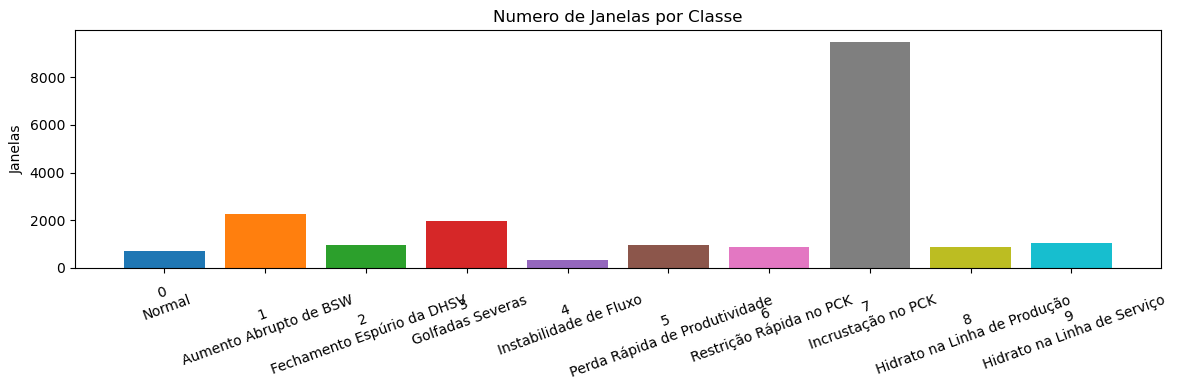

Janelas por classe:
  0 — Normal                             :    709
  1 — Aumento Abrupto de BSW             :  2,251
  2 — Fechamento Espúrio da DHSV         :    950
  3 — Golfadas Severas                   :  1,959
  4 — Instabilidade de Fluxo             :    350
  5 — Perda Rápida de Produtividade      :    970
  6 — Restrição Rápida no PCK            :    890
  7 — Incrustação no PCK                 :  9,499
  8 — Hidrato na Linha de Produção       :    890
  9 — Hidrato na Linha de Serviço        :  1,054


In [9]:
window_counts = df['fault_class'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
labels = [f'{k}\n{FAULT_CLASSES[k]}' for k in window_counts.index]
ax.bar(labels, window_counts.values, color=sns.color_palette('tab10', 10))
ax.set_title('Numero de Janelas por Classe')
ax.set_ylabel('Janelas')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print('Janelas por classe:')
for k, v in window_counts.items():
    print(f'  {k} — {FAULT_CLASSES[k]:<35}: {v:>6,}')

## 3.3 Qualidade: NaN nas features

Janelas muito curtas (no início ou fim de uma instância) podem gerar NaN em algumas features.
Na modelagem, usaremos um `SimpleImputer` para substituir esses valores pela mediana.

In [10]:
nan_counts = df[feature_cols].isna().sum()
cols_with_nan = nan_counts[nan_counts > 0].sort_values(ascending=False)

if cols_with_nan.empty:
    print('Nenhuma feature com NaN — dataset pronto para modelagem!')
else:
    print(f'{len(cols_with_nan)} features com NaN (serao tratadas com SimpleImputer na Etapa 4):')
    print(cols_with_nan.head(10).to_string())

44 features com NaN (serao tratadas com SimpleImputer na Etapa 4):
T-PDG_mean         18463
T-PDG_std          18463
T-PDG_min          18463
T-PDG_max          18463
T-PDG_skewness     18463
T-PDG_kurtosis     18463
T-PDG_median       18463
T-PDG_iqr          18463
T-PDG_diff1_std    18463
T-PDG_diff2_std    18463


## 3.4 Features com maior variância

Features com variância próxima de zero não trazem informação — o modelo as ignoraria.
Features com alta variância são candidatas a ser importantes para a classificação.

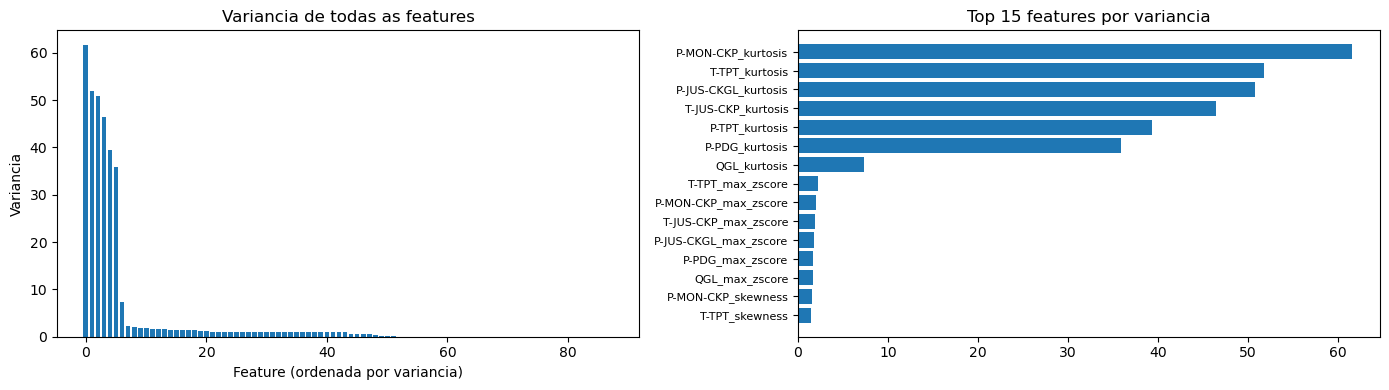

In [11]:
variances = df[feature_cols].var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Todas as features
axes[0].bar(range(len(variances)), variances.values)
axes[0].set_title('Variancia de todas as features')
axes[0].set_xlabel('Feature (ordenada por variancia)')
axes[0].set_ylabel('Variancia')

# Top 15
top15 = variances.head(15)
axes[1].barh(range(len(top15)), top15.values)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels(top15.index, fontsize=8)
axes[1].set_title('Top 15 features por variancia')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3.5 Separabilidade entre classes (boxplot de uma feature)

Para uma feature ser útil, ela precisa ter distribuições **diferentes** entre as classes.
Aqui comparamos a feature de maior variância entre as 10 classes.

C:\Users\rabel\AppData\Local\Temp\ipykernel_22928\1556209871.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True,


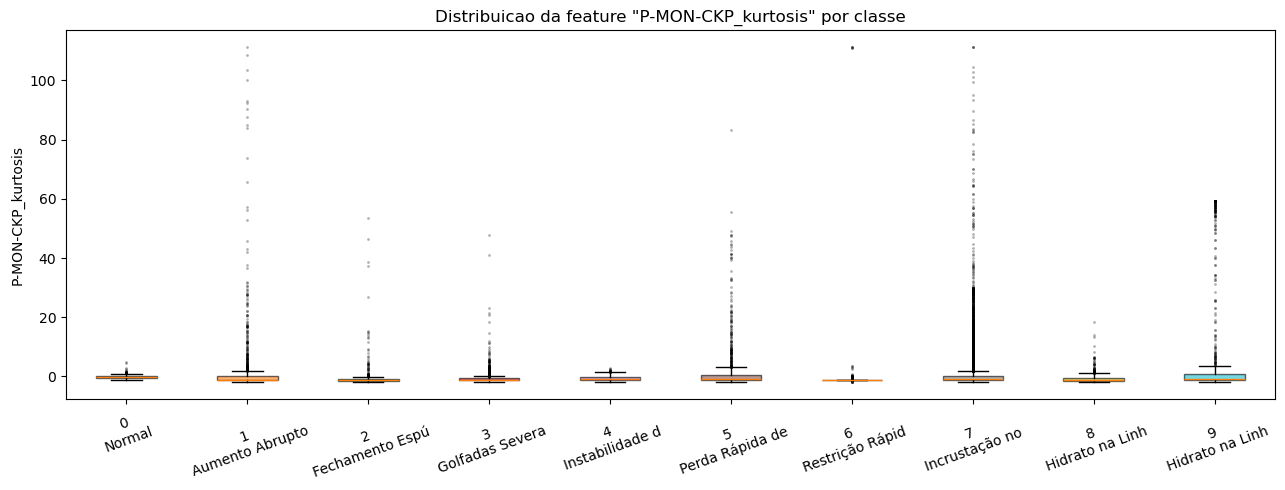

Feature analisada: P-MON-CKP_kurtosis
Se as caixas estao em alturas diferentes, a feature ajuda a separar as classes.


In [12]:
best_feature = variances.index[0]

fig, ax = plt.subplots(figsize=(13, 5))
data_by_class = [df[df['fault_class'] == c][best_feature].dropna().values
                 for c in sorted(FAULT_CLASSES)]
labels = [f'{k}\n{FAULT_CLASSES[k][:15]}' for k in sorted(FAULT_CLASSES)]

bp = ax.boxplot(data_by_class, labels=labels, patch_artist=True,
                flierprops=dict(marker='.', markersize=2, alpha=0.3))

colors = sns.color_palette('tab10', 10)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_title(f'Distribuicao da feature "{best_feature}" por classe')
ax.set_ylabel(best_feature)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print(f'Feature analisada: {best_feature}')
print('Se as caixas estao em alturas diferentes, a feature ajuda a separar as classes.')